#### 데이터 불러오기

In [1]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(('data/bank.csv'))
df=pd.DataFrame(data)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  campaign   45211 non-null  int64 
 12  pdays      45211 non-null  int64 
 13  previous   45211 non-null  int64 
 14  poutcome   45211 non-null  object
 15  y          45211 non-null  object
dtypes: int64(6), object(10)
memory usage: 5.5+ MB


In [4]:
df.shape

(45211, 16)

#### 결측값 확인

In [5]:
nan_sum_column = df.isnull().sum()
nan_sum_row = df.isnull().sum(axis=1)
print('nan_sum_column:\n',nan_sum_column,'\nnan_sum_row:\n',nan_sum_row)
print('총 결측치 개수:',df.isnull().sum().sum())

nan_sum_column:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64 
nan_sum_row:
 0        0
1        0
2        0
3        0
4        0
        ..
45206    0
45207    0
45208    0
45209    0
45210    0
Length: 45211, dtype: int64
총 결측치 개수: 0


#### 이상치 확인

In [6]:
df.describe(include='all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,3.000000,-1.000000,0.000000,NaN,NaN


balance(연평균 통장 잔고)의 음수 값은 마이너스 통장을 의미하므로, 이상치에 해당하지 않는다. pdays(이전 캠페인 기간 이전에 고객에게 연락한 횟수)가 -1인것은 해당 고객에게 연락한적 없다는 것을 의미하므로 이상치에 해당하지 않는다.

#### 중복 데이터 확인

In [7]:
df.duplicated().sum()

np.int64(16)

In [8]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(45195, 16)

In [12]:
numeric_list =df.select_dtypes(include='number').columns.tolist()
categorical_list = df.select_dtypes(include='object').columns.tolist()
print('numeric_list:',numeric_list)
print('categorical_list:',categorical_list)

numeric_list: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
categorical_list: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


#### balance (연평균 통장 잔고)

- 정기예금 가입자와 비가입자 간에 연평균 통장 잔고의 차이가 존재하는지 분포를 비교해본다. 정기예금 가입자 여부는 y 컬럼의 값으로 식별 가능하며, 'yes'면 가입자, 'no'면 비가입자입니다.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
plt.rcParams['figure.figsize'] = (20, 5)  # Matplotlib 라이브러리를 사용하여 향후 시각화할 모든 그래프의 크기를 미리 조정해 두겠습니다. (가로 20인치, 세로 5인치)

/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


yes_mean: 1,804.27 
 no_mean: 1,304.24


/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_

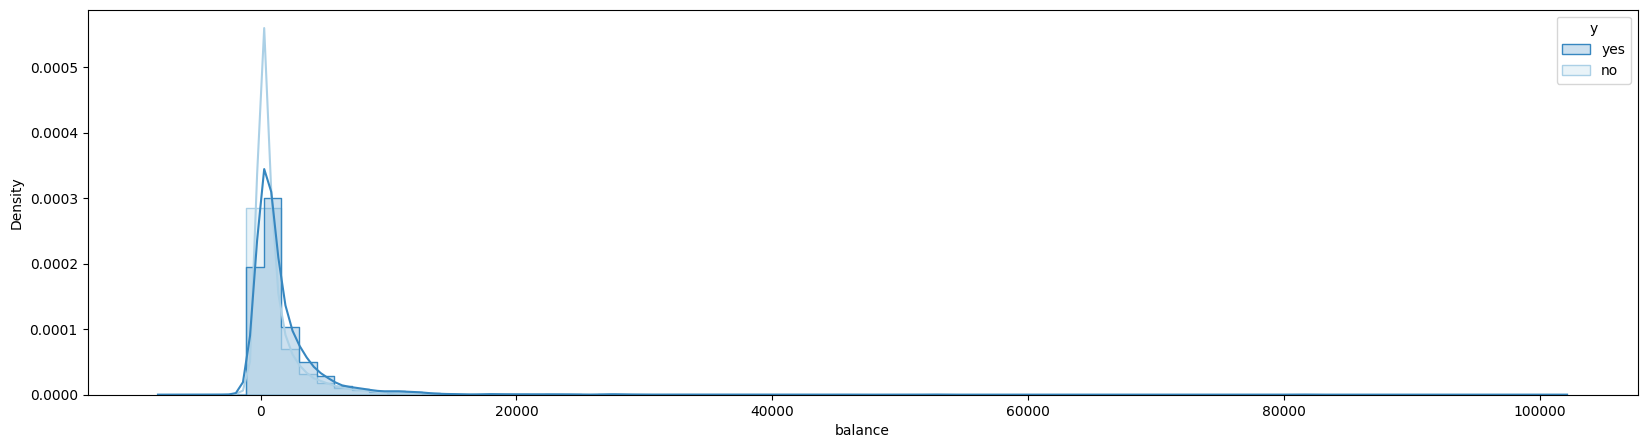

In [15]:
sns.histplot(data=df, x='balance', hue='y',
             common_norm=False,  # 두 그룹 (가입자 & 비가입자) 간의 분포를 각각 따로 정규화(normalize)하겠다는 의미입니다.
             kde=True, stat='density',  # 히스토그램과 함께 KDE plot을 함께 그려주는 옵션입니다. stat='density'를 넣지 않으면 y축은 단순 수치로 표기됩니다.
             bins=80,  # bin 값을 조정해 줍니다.
             element='step',  # 두 그룹의 분포를 조금 더 구분되어 보이게 해주는 시각화 모드입니다.
             hue_order=['yes', 'no'], palette='Blues_r')  # hue에 들어간 변수의 순서를 조정해 주고, 팔레트를 설정해 주었습니다.


# 각 그룹의 평균값을 함께 출력해 줍니다.
yes_mean = df.query('y == "yes"')['balance'].mean()
no_mean = df.query('y == "no"')['balance'].mean()
print(f"yes_mean: {yes_mean:,.2f} \n no_mean: {no_mean:,.2f}")

정기 예금 가입자 그룹의 평균 통장 잔고가 조금 더 높은 경향이 있다.

#### Camplaign (이번 캠페인 기간 동안의 연락 횟수)

/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


yes_mean: 2.14 
 no_mean: 2.85


/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_

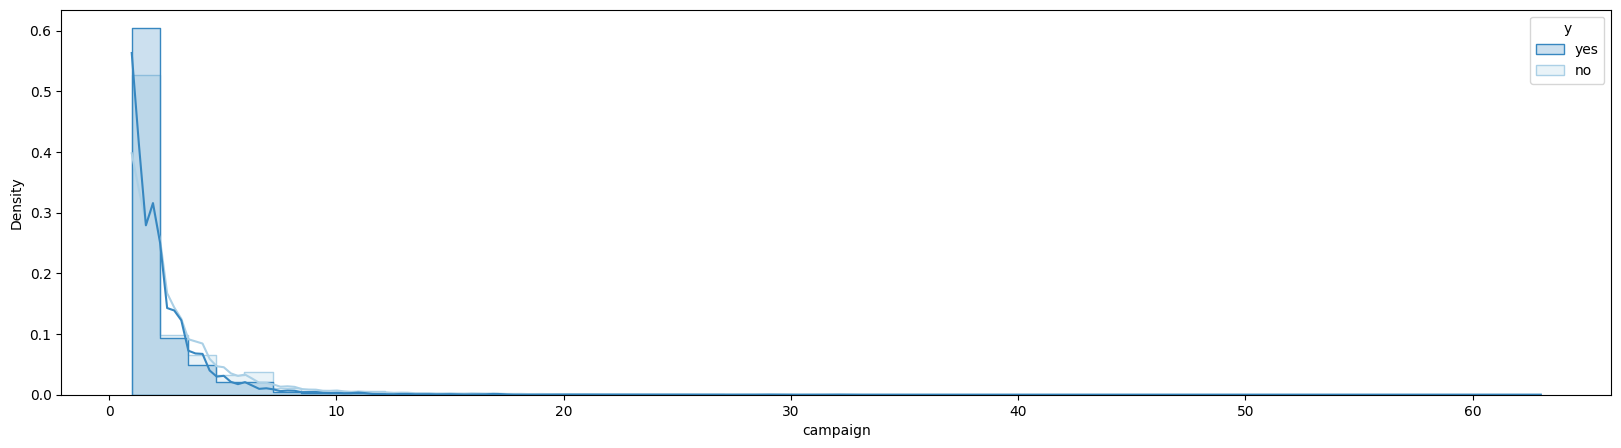

In [16]:
sns.histplot(data=df, x='campaign', hue='y',
             common_norm=False, kde=True, stat='density', bins=50, element='step',
             hue_order=['yes', 'no'], palette='Blues_r')


# 각 그룹의 평균값을 함께 출력해 줍니다.
yes_mean = df.query('y == "yes"')['campaign'].mean()
no_mean = df.query('y == "no"')['campaign'].mean()
print(f"yes_mean: {yes_mean:,.2f} \n no_mean: {no_mean:,.2f}")

차이가 거의 나지 않지만, 가입자보다 오히려 비가입자가 캠페인 기간 동안의 평균 연락 횟수가 조금 더 많았다.

#### pdays (이전 캠페인 기간의 마지막 연락 이후 경과 일수)

/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_

yes_mean: 192.52 
 no_mean: 234.19


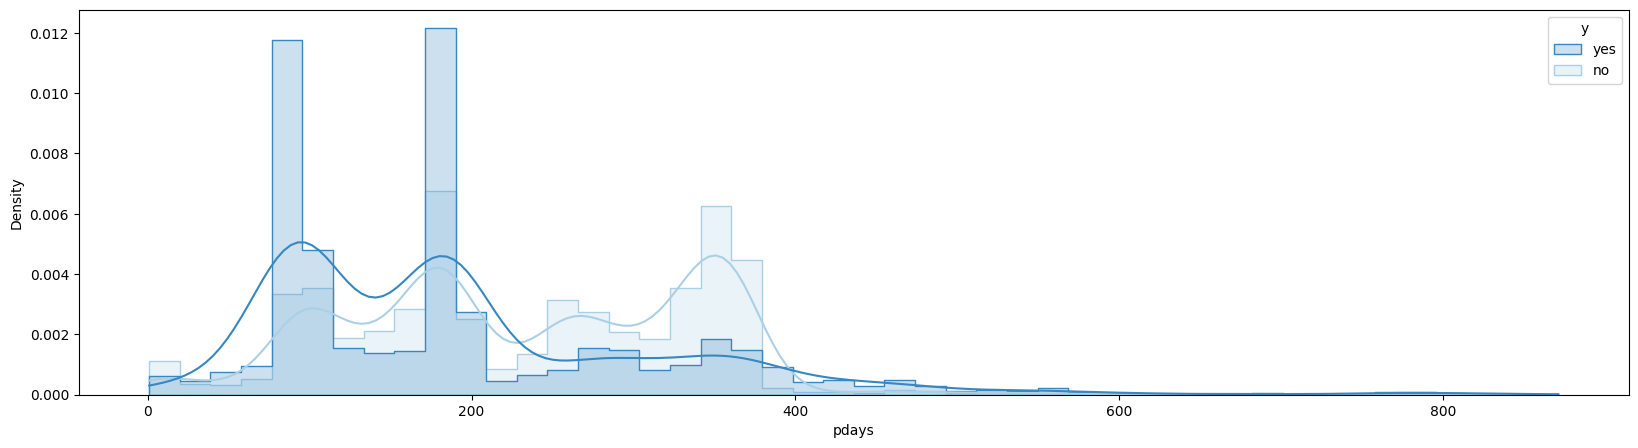

In [17]:
# 값이 -1인 경우 이전에 연락을 한 적이 없다는 의미이므로 제외합니다.
temp_df = df.query('pdays != -1')

sns.histplot(data=temp_df, x='pdays', hue='y',
             common_norm=False, kde=True, stat='density', element='step',
             hue_order=['yes', 'no'], palette='Blues_r')


# 각 그룹의 평균값을 함께 출력해 줍니다.
yes_mean = temp_df.query('y == "yes"')['pdays'].mean()
no_mean = temp_df.query('y == "no"')['pdays'].mean()
print(f"yes_mean: {yes_mean:,.2f} \n no_mean: {no_mean:,.2f}")

가입자보다 비가입자 중에 마지막 연락 이후 경과일수가 긴 고객의 비중이 높은 것으로 보인다.

#### age(연령)

/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


yes_mean: 41.67 
 no_mean: 40.84


/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_

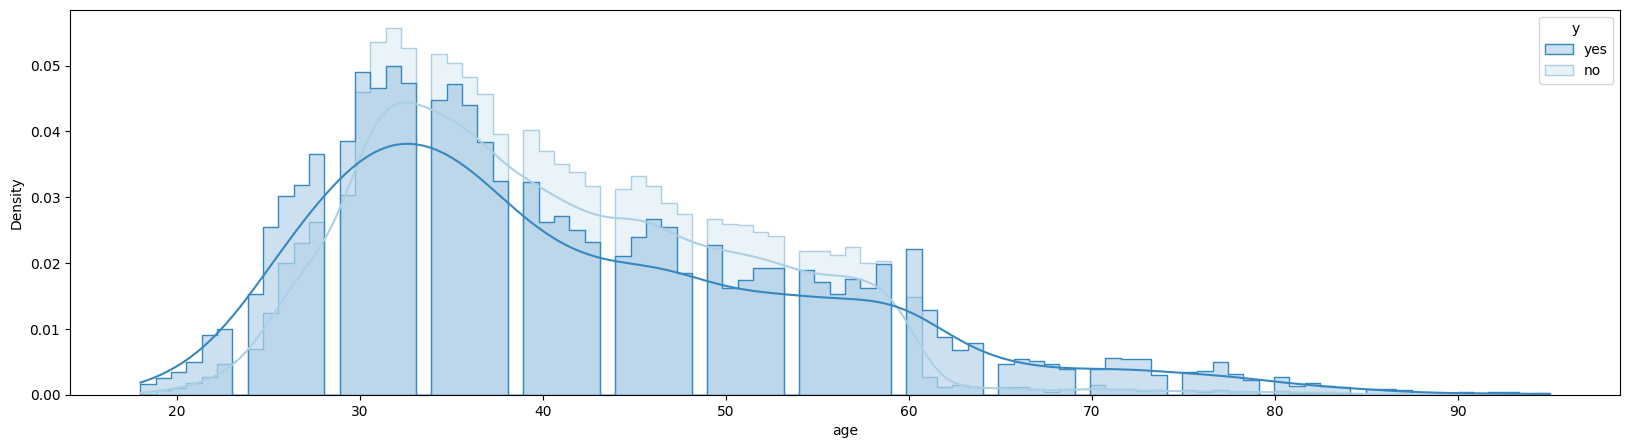

In [18]:
sns.histplot(data=df, x='age', hue='y',
             common_norm=False, kde=True, stat='density', element='step',
             hue_order=['yes', 'no'], palette='Blues_r')


# 각 그룹의 평균값을 함께 출력해 줍니다.
yes_mean = df.query('y == "yes"')['age'].mean()
no_mean = df.query('y == "no"')['age'].mean()
print(f"yes_mean: {yes_mean:,.2f} \n no_mean: {no_mean:,.2f}")

가입자가 비가입자에 비해 30세 미만의 젊은 연령층 & 60대 이상의 고 연령층 비율이 높은 것으로 보인다. 그러다 보니 평균 연령은 가입자가 비가입자에 비해 소폭 높게 나타나는데, 가입자 측에 양 극단에 속하는 고객의 비중이 높다보니 평균값으로 비교하는 것은 적절치 않아 보인다.

In [19]:
def age_category(age):
    if age < 20:
        return '10s'
    elif age < 30:
        return '20s'
    elif age < 40:
        return '30s'
    elif age < 50:
        return '40s'
    elif age < 60:
        return '50s'
    elif age >= 60:
        return '60s+'
    else:
        return 'unknown'
    
df['age_cat'] = df['age'].apply(age_category)

age_distribution_df=pd.pivot_table(data=df, index='y', columns='age_cat', values='job', aggfunc='count')
age_distribution_df

age_cat,10s,20s,30s,40s,50s,60s+
y,,,,,,
no,29,4315,16166,10588,7624,1184
yes,18,910,1913,1063,785,600


In [20]:
# age_distribution_df.sum(axis=1) 코드를 통해 가로 방향 합산값을 구한 후, 각 값을 이 수치로 나눠 연령대 비율을 계산합니다.
age_distribution_ratio_df = age_distribution_df.div(age_distribution_df.sum(axis=1), axis=0) * 100
age_distribution_ratio_df

age_cat,10s,20s,30s,40s,50s,60s+
y,,,,,,
no,0.072671,10.812910,40.510199,26.532351,19.104897,2.966972
yes,0.340329,17.205521,36.169408,20.098317,14.842125,11.344299


가입자 그룹에서는 상대적으로 20대 이하의 젊은 층과 60대 이상의 고연령층 비중이 높은 편이고, 비가입자 그룹에서는 반대로 30대~50대의 중간 연령층 비중이 상대적으로 높습니다.

#### 범주형 변수 탐구

- job

가입자와 비가입자 그룹 내에서 직업별 비율 차이가 있는지 확인해본다.

In [21]:
count_df=df.groupby(['y','job']).size().reset_index(name='count')
count_df

,y,job,count
0,no,admin.,4540
1,no,blue-collar,9022
2,no,entrepreneur,1364
3,no,housemaid,1131
4,no,management,8150
5,no,retired,1747
6,no,self-employed,1392
7,no,services,3783
8,no,student,669
9,no,technician,6753


In [22]:
count_df['percentage'] = count_df.groupby('y')['count'].transform(lambda x: x / x.sum())
count_df

,y,job,count,percentage
0,no,admin.,4540,0.113767
1,no,blue-collar,9022,0.226081
2,no,entrepreneur,1364,0.034180
3,no,housemaid,1131,0.028342
4,no,management,8150,0.204230
5,no,retired,1747,0.043778
6,no,self-employed,1392,0.034882
7,no,services,3783,0.094798
8,no,student,669,0.016764
9,no,technician,6753,0.169223


/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


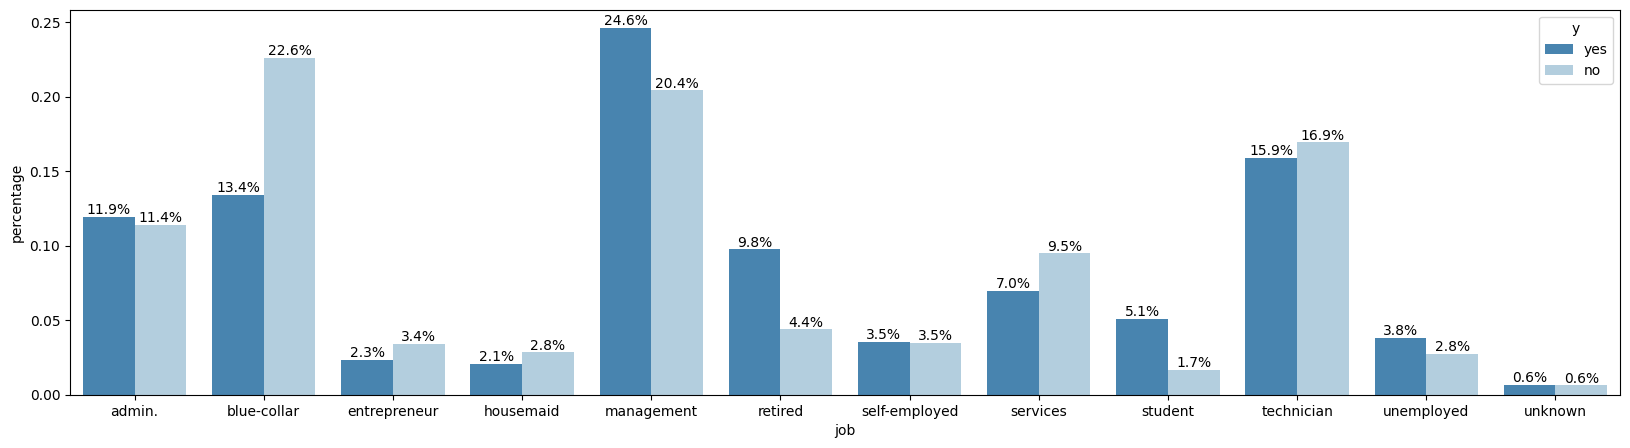

In [23]:
fig, ax = plt.subplots()
sns.barplot(data=count_df, x="job", y="percentage", hue="y", hue_order=['yes', 'no'], palette="Blues_r", ax=ax)

# 막대 위에 해당되는 수치를 함께 시각화해 주는 코드입니다.
for c in ax.containers:
    ax.bar_label(c, fmt='{:.1%}');  # fmt = format. 소수점 한자리까지의 % 형태로 값을 나타내겠다는 의미입니다.

가입자 그룹에서 상대적으로 경영직(management), 은퇴자(retired), 학생(student)의 비중이 높은 편으로 나타납니다. 특히, 경영직 고객은 가입자 중 절대적인 비중도 가장 높기 때문에 주요 공략 대상이 될 수 있다고 판단됩니다.

- martial(결혼상태)

/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


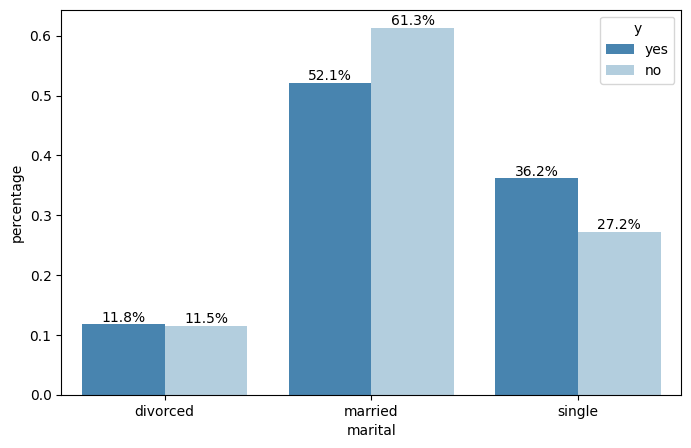

In [24]:
count_df = df.groupby(['y', 'marital']).size().reset_index(name='count')
count_df['percentage'] = count_df.groupby('y')['count'].transform(lambda x: x / x.sum())

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=count_df, x="marital", y="percentage", hue="y", hue_order=['yes', 'no'], palette="Blues_r", ax=ax)

for c in ax.containers:
    ax.bar_label(c, fmt='{:.1%}');

가입자 그룹에서 상대적으로 미혼(single)의 비중이 높은 편으로 나타납니다. 다만 기혼(married) 고객이 절대적으로 많은 편이다 보니 실제 가입자 내에서 가장 많은 비중을 차지하는 건 기혼 고객들입니다.

- education(교육)

/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


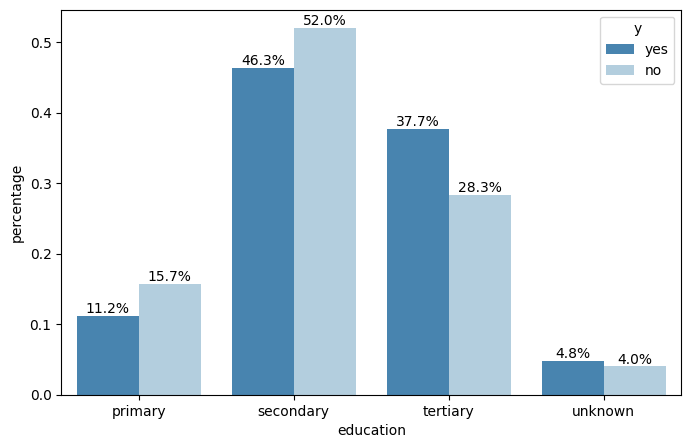

In [25]:
count_df = df.groupby(['y', 'education']).size().reset_index(name='count')
count_df['percentage'] = count_df.groupby('y')['count'].transform(lambda x: x / x.sum())

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=count_df, x="education", y="percentage", hue="y", hue_order=['yes', 'no'], palette="Blues_r", ax=ax)

for c in ax.containers:
    ax.bar_label(c, fmt='{:.1%}');

가입자 그룹에서 상대적으로 고등 교육(tertiary)까지 이수한 고객의 비중이 높은 편으로 나타납니다. 다만 절대적인 고객수의 차이 영향으로 실제 가입자 내에서 가장 많은 비중을 차지하는 건 중등 교육(secondary)까지 이수한 고객입니다.